In [1]:
# --- Step 1.1: Import Libraries ---
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns
from scipy import stats
import warnings
warnings.filterwarnings('ignore')

In [2]:
#  Set plot style
sns.set_theme(style="whitegrid")
plt.rcParams['figure.dpi'] = 120
plt.rcParams['font.size'] = 11
 
print("=" * 60)
print("TASK 1: DATA CLEANING AND FORMATTING")
print("=" * 60)

TASK 1: DATA CLEANING AND FORMATTING


In [4]:
df = pd.read_csv(r"D:\Amar_project\data\blackrock (1).csv")
print(f"\nOriginal Shape: {df.shape}")
print("\nFirst 5 rows:")
print(df.head())


Original Shape: (800, 15)

First 5 rows:
   TransactionID CustomerID AccountID AccountType TransactionType  \
0            109   CUST1913  ACC64393      Credit      Withdrawal   
1             19   CUST1569  ACC66190     Current         Payment   
2             14   CUST5558  ACC71426     Current      Withdrawal   
3            107   CUST4241  ACC49422        Loan         Deposit   
4              7   CUST2578  ACC88252        Loan         Deposit   

           Product    Firm   Region    Manager TransactionDate  \
0        Home Loan  Firm A     West  Manager 1      17-07-2023   
1    Personal Loan  Firm C    South  Manager 4      13-01-2023   
2      Mutual Fund  Firm C    North  Manager 2      28-09-2023   
3      Credit Card  Firm D  Central  Manager 1      05-02-2023   
4  Savings Account  Firm B     East  Manager 4      19-11-2023   

   TransactionAmount  AccountBalance  RiskScore  CreditRating  TenureMonths  
0        47387.11457     2980.571037   0.780701           784       

In [5]:
# Basic Info
print("\nDataset Info:")
print(df.info())
print("\nMissing Values:")
print(df.isnull().sum())
print("\nBasic Statistics:")
print(df.describe())


Dataset Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 800 entries, 0 to 799
Data columns (total 15 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   TransactionID      800 non-null    int64  
 1   CustomerID         800 non-null    object 
 2   AccountID          800 non-null    object 
 3   AccountType        800 non-null    object 
 4   TransactionType    800 non-null    object 
 5   Product            800 non-null    object 
 6   Firm               800 non-null    object 
 7   Region             800 non-null    object 
 8   Manager            800 non-null    object 
 9   TransactionDate    800 non-null    object 
 10  TransactionAmount  800 non-null    float64
 11  AccountBalance     800 non-null    float64
 12  RiskScore          800 non-null    float64
 13  CreditRating       800 non-null    int64  
 14  TenureMonths       800 non-null    int64  
dtypes: float64(3), int64(3), object(9)
memory usage: 93.9+ KB
N

In [6]:
financial_cols = ['TransactionAmount', 'AccountBalance', 'RiskScore', 'CreditRating']
 
print("\n--- Checking Financial Columns for Issues ---")
for col in financial_cols:
    print(f"{col}: dtype={df[col].dtype}, nulls={df[col].isnull().sum()}")


--- Checking Financial Columns for Issues ---
TransactionAmount: dtype=float64, nulls=0
AccountBalance: dtype=float64, nulls=0
RiskScore: dtype=float64, nulls=0
CreditRating: dtype=int64, nulls=0


In [7]:
# Convert to numeric (coerce errors turns bad values into NaN)
for col in financial_cols:
    df[col] = pd.to_numeric(df[col], errors='coerce')
 
print("\nAfter numeric conversion - NaN counts:")
print(df[financial_cols].isnull().sum())


After numeric conversion - NaN counts:
TransactionAmount    0
AccountBalance       0
RiskScore            0
CreditRating         0
dtype: int64


In [8]:
#  Drop rows where critical financial data is missing (cannot be imputed safely)
before = len(df)
df.dropna(subset=['TransactionAmount', 'AccountBalance'], inplace=True)
after = len(df)
print(f"\nRows dropped due to missing financial data: {before - after}")
print(f"Dataset size after cleaning: {df.shape}")


Rows dropped due to missing financial data: 0
Dataset size after cleaning: (800, 15)


In [9]:
# Convert Currency - Ensure Numeric Format ---
# TransactionAmount and AccountBalance are already numeric after above step
# Round to 2 decimal places for currency formatting
df['TransactionAmount'] = df['TransactionAmount'].round(2)
df['AccountBalance'] = df['AccountBalance'].round(2)
print("\nCurrency columns formatted to 2 decimal places ✓")


Currency columns formatted to 2 decimal places ✓


In [10]:
# Validate and Format Date Column ---
df['TransactionDate'] = pd.to_datetime(df['TransactionDate'], format='%d-%m-%Y', errors='coerce')
print(f"\nDate conversion: {df['TransactionDate'].isnull().sum()} invalid dates found")
df.dropna(subset=['TransactionDate'], inplace=True)


Date conversion: 0 invalid dates found


In [11]:
# Extract useful time features
df['Year'] = df['TransactionDate'].dt.year
df['Month'] = df['TransactionDate'].dt.month
df['MonthName'] = df['TransactionDate'].dt.strftime('%b')
df['YearMonth'] = df['TransactionDate'].dt.to_period('M')
df['Quarter'] = df['TransactionDate'].dt.quarter
 
print("\nDate range in dataset:")
print(f"  Earliest: {df['TransactionDate'].min().date()}")
print(f"  Latest:   {df['TransactionDate'].max().date()}")


Date range in dataset:
  Earliest: 2023-01-06
  Latest:   2024-06-22


In [12]:
#  Standardize Account Types and Transaction Categories ---
print("\n--- Before Standardization ---")
print("AccountType unique values:", df['AccountType'].unique())
print("TransactionType unique values:", df['TransactionType'].unique())


--- Before Standardization ---
AccountType unique values: ['Credit' 'Current' 'Loan' 'Savings']
TransactionType unique values: ['Withdrawal' 'Payment' 'Deposit' 'Transfer']


In [13]:
# Strip whitespace and title-case standardization
df['AccountType'] = df['AccountType'].str.strip().str.title()
df['TransactionType'] = df['TransactionType'].str.strip().str.title()
df['Product'] = df['Product'].str.strip().str.title()
df['Region'] = df['Region'].str.strip().str.title()
df['Firm'] = df['Firm'].str.strip().str.title()
df['Manager'] = df['Manager'].str.strip().str.title()
 
print("\n--- After Standardization ---")
print("AccountType unique values:", df['AccountType'].unique())
print("TransactionType unique values:", df['TransactionType'].unique())


--- After Standardization ---
AccountType unique values: ['Credit' 'Current' 'Loan' 'Savings']
TransactionType unique values: ['Withdrawal' 'Payment' 'Deposit' 'Transfer']


In [14]:
# Final Cleaned Dataset ---
print(f"\n✓ Final cleaned dataset shape: {df.shape}")
print("\nCleaned DataFrame (first 5 rows):")
print(df.head())


✓ Final cleaned dataset shape: (800, 20)

Cleaned DataFrame (first 5 rows):
   TransactionID CustomerID AccountID AccountType TransactionType  \
0            109   CUST1913  ACC64393      Credit      Withdrawal   
1             19   CUST1569  ACC66190     Current         Payment   
2             14   CUST5558  ACC71426     Current      Withdrawal   
3            107   CUST4241  ACC49422        Loan         Deposit   
4              7   CUST2578  ACC88252        Loan         Deposit   

           Product    Firm   Region    Manager TransactionDate  \
0        Home Loan  Firm A     West  Manager 1      2023-07-17   
1    Personal Loan  Firm C    South  Manager 4      2023-01-13   
2      Mutual Fund  Firm C    North  Manager 2      2023-09-28   
3      Credit Card  Firm D  Central  Manager 1      2023-02-05   
4  Savings Account  Firm B     East  Manager 4      2023-11-19   

   TransactionAmount  AccountBalance  RiskScore  CreditRating  TenureMonths  \
0           47387.11         298

In [15]:
# Save cleaned data
df.to_csv("blackrock_cleaned.csv", index=False)
print("\n✓ Cleaned data saved as 'blackrock_cleaned.csv'")


✓ Cleaned data saved as 'blackrock_cleaned.csv'


In [16]:
print("\n" + "=" * 60)
print("TASK 2: DESCRIPTIVE TRANSACTIONAL ANALYSIS")
print("=" * 60)


TASK 2: DESCRIPTIVE TRANSACTIONAL ANALYSIS


In [17]:
# Label Credits and Debits ---
# Deposits = Credits | Withdrawals, Payments = Debits | Transfers = Neutral
credit_types = ['Deposit']
debit_types  = ['Withdrawal', 'Payment']
 
df['IsCredit'] = df['TransactionType'].isin(credit_types)
df['IsDebit']  = df['TransactionType'].isin(debit_types)
df['CreditAmount'] = df['TransactionAmount'].where(df['IsCredit'], 0)
df['DebitAmount']  = df['TransactionAmount'].where(df['IsDebit'], 0)

In [18]:
# Monthly Summary ---
monthly = df.groupby('YearMonth').agg(
    TotalCredits  = ('CreditAmount', 'sum'),
    TotalDebits   = ('DebitAmount',  'sum'),
    NetVolume     = ('TransactionAmount', 'sum'),
    TxnCount      = ('TransactionID', 'count')
).reset_index()
monthly['YearMonth_str'] = monthly['YearMonth'].astype(str)
 
print("\n--- Monthly Summary (Credits, Debits, Net Volume) ---")
print(monthly.to_string(index=False))


--- Monthly Summary (Credits, Debits, Net Volume) ---
YearMonth  TotalCredits  TotalDebits  NetVolume  TxnCount YearMonth_str
  2023-01     453287.77   1329907.26 2232178.60        48       2023-01
  2023-02     556591.27   1674317.60 3166694.88        54       2023-02
  2023-03     405511.18   1397222.53 2319202.56        39       2023-03
  2023-04     328957.76   1273478.37 2099603.46        40       2023-04
  2023-05     933558.82   1320213.14 3275217.59        67       2023-05
  2023-06     676082.46    531862.98 1665546.91        32       2023-06
  2023-07     486549.76   1047056.85 1909447.27        35       2023-07
  2023-08      81985.14   1511240.06 2015693.90        40       2023-08
  2023-09     749147.40   1565613.91 2944917.47        52       2023-09
  2023-10    1322051.68   1973336.69 4168319.16        73       2023-10
  2023-11     966178.34   1337323.21 2950693.66        50       2023-11
  2023-12     522862.17    622996.29 1726963.98        33       2023-12
  2024-01

In [19]:
# Yearly Summary ---
yearly = df.groupby('Year').agg(
    TotalCredits = ('CreditAmount', 'sum'),
    TotalDebits  = ('DebitAmount',  'sum'),
    NetVolume    = ('TransactionAmount', 'sum'),
    TxnCount     = ('TransactionID', 'count')
).reset_index()
 
print("\n--- Yearly Summary ---")
print(yearly.to_string(index=False))


--- Yearly Summary ---
 Year  TotalCredits  TotalDebits   NetVolume  TxnCount
 2023    7482763.75  15584568.89 30474479.44       563
 2024    3262322.08   6863625.40 13127013.84       237


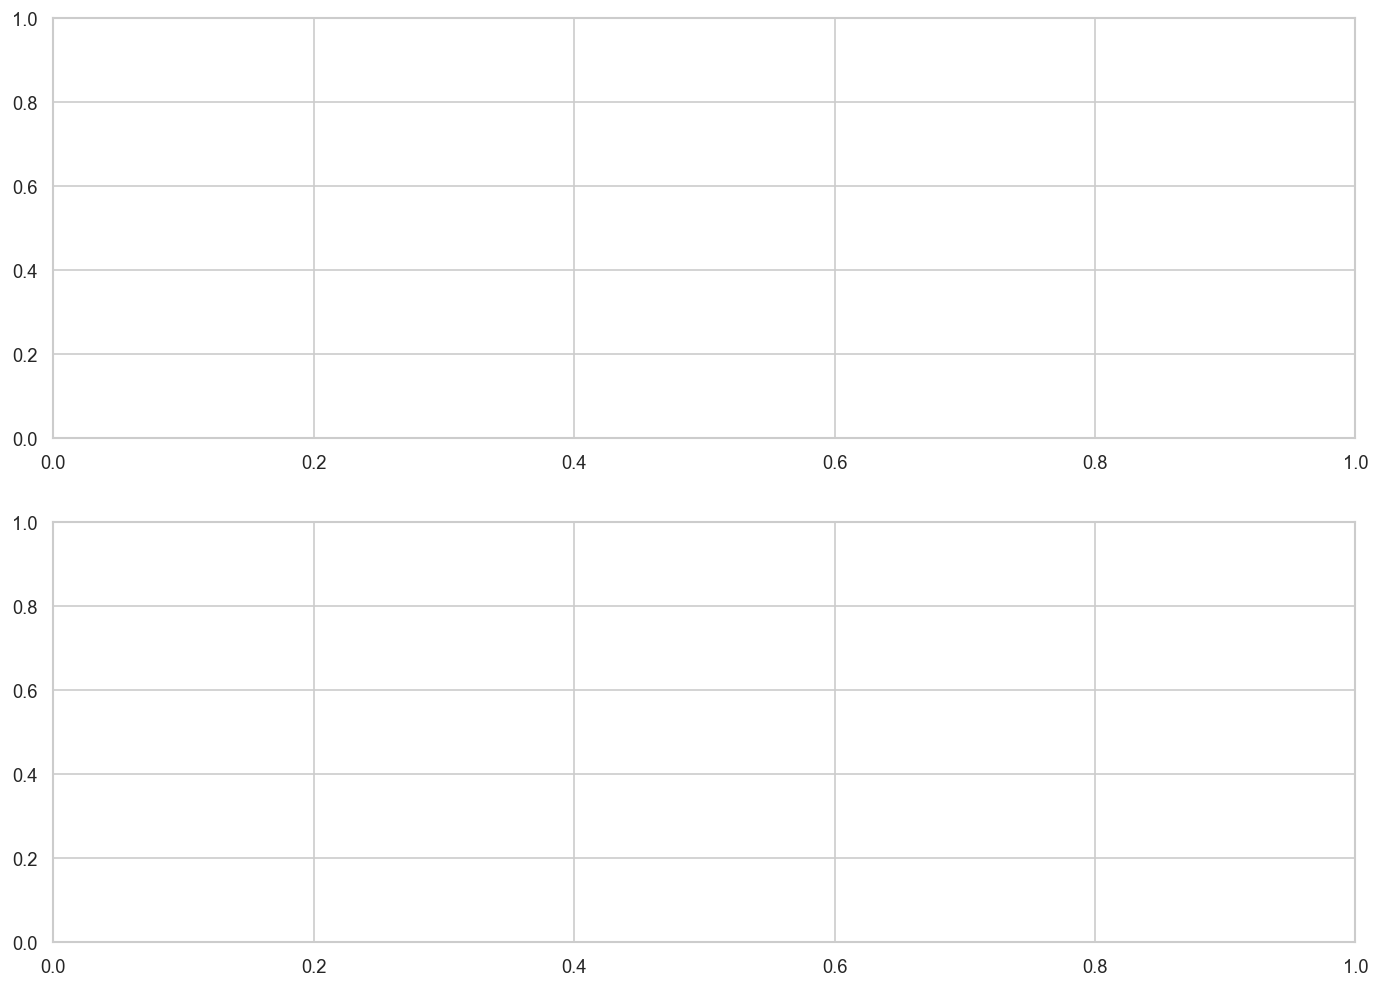

In [20]:
# Plot Trends - Credits vs Debits Over Time ---
fig, axes = plt.subplots(2, 1, figsize=(14, 10))

In [21]:
# Monthly trend
ax1 = axes[0]
ax1.plot(monthly['YearMonth_str'], monthly['TotalCredits']/1e6,
         marker='o', color='green', label='Total Credits', linewidth=2)
ax1.plot(monthly['YearMonth_str'], monthly['TotalDebits']/1e6,
         marker='s', color='red', label='Total Debits', linewidth=2)
ax1.fill_between(monthly['YearMonth_str'], monthly['TotalCredits']/1e6,
                 monthly['TotalDebits']/1e6, alpha=0.1, color='blue')
ax1.set_title('Monthly Credits vs Debits Over Time', fontsize=13, fontweight='bold')
ax1.set_xlabel('Year-Month')
ax1.set_ylabel('Amount (Millions)')
ax1.legend()
ax1.tick_params(axis='x', rotation=45)

In [22]:
# Yearly trend
ax2 = axes[1]
x = np.arange(len(yearly))
width = 0.35
ax2.bar(x - width/2, yearly['TotalCredits']/1e6, width, color='green', label='Total Credits', alpha=0.8)
ax2.bar(x + width/2, yearly['TotalDebits']/1e6, width, color='red', label='Total Debits', alpha=0.8)
ax2.set_title('Yearly Credits vs Debits', fontsize=13, fontweight='bold')
ax2.set_xlabel('Year')
ax2.set_ylabel('Amount (Millions)')
ax2.set_xticks(x)
ax2.set_xticklabels(yearly['Year'].astype(str))
ax2.legend()
 
plt.tight_layout()
plt.savefig('task2_credits_debits_trend.png', bbox_inches='tight')
plt.show()
print("✓ Plot saved: task2_credits_debits_trend.png")

<Figure size 768x576 with 0 Axes>

✓ Plot saved: task2_credits_debits_trend.png


In [23]:
# Top and Bottom Performing Accounts by Net Inflow ---
account_summary = df.groupby('AccountID').agg(
    TotalCredits   = ('CreditAmount', 'sum'),
    TotalDebits    = ('DebitAmount',  'sum'),
    TxnCount       = ('TransactionID', 'count'),
    AvgBalance     = ('AccountBalance', 'mean'),
    LastTxnDate    = ('TransactionDate', 'max'),
    FirstTxnDate   = ('TransactionDate', 'min')
).reset_index()
account_summary['NetInflow'] = account_summary['TotalCredits'] - account_summary['TotalDebits']
 
top5    = account_summary.nlargest(5, 'NetInflow')[['AccountID','NetInflow','TxnCount','AvgBalance']]
bottom5 = account_summary.nsmallest(5, 'NetInflow')[['AccountID','NetInflow','TxnCount','AvgBalance']]
 
print("\n--- TOP 5 Accounts by Net Inflow ---")
print(top5.to_string(index=False))
print("\n--- BOTTOM 5 Accounts by Net Inflow ---")
print(bottom5.to_string(index=False))


--- TOP 5 Accounts by Net Inflow ---
AccountID  NetInflow  TxnCount  AvgBalance
 ACC88286  284230.59         5  71284.1900
 ACC21719  274729.19         4  72818.1125
 ACC51200  201469.72         4  72388.0125
 ACC28295  199450.69         4 125043.3100
 ACC88252  183519.25         5  86094.9000

--- BOTTOM 5 Accounts by Net Inflow ---
AccountID  NetInflow  TxnCount   AvgBalance
 ACC45101 -395419.95         7 65679.954286
 ACC35419 -365901.21         6 53390.330000
 ACC97411 -365710.86         8 89407.828750
 ACC71938 -353666.21         4 54440.037500
 ACC24070 -338136.69         5 53811.390000


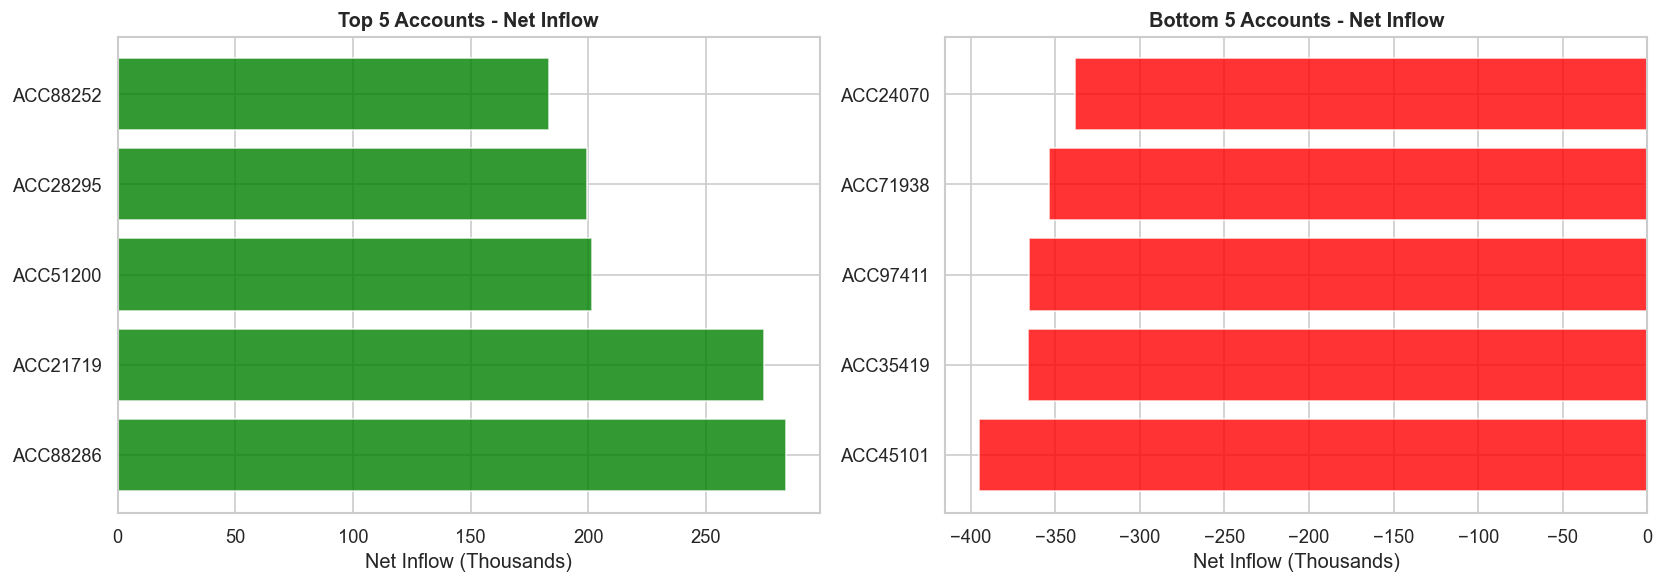

✓ Plot saved: task2_top_bottom_accounts.png


In [24]:
# Plot top/bottom accounts
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
 
axes[0].barh(top5['AccountID'], top5['NetInflow']/1e3, color='green', alpha=0.8)
axes[0].set_title('Top 5 Accounts - Net Inflow', fontweight='bold')
axes[0].set_xlabel('Net Inflow (Thousands)')
 
axes[1].barh(bottom5['AccountID'], bottom5['NetInflow']/1e3, color='red', alpha=0.8)
axes[1].set_title('Bottom 5 Accounts - Net Inflow', fontweight='bold')
axes[1].set_xlabel('Net Inflow (Thousands)')
 
plt.tight_layout()
plt.savefig('task2_top_bottom_accounts.png', bbox_inches='tight')
plt.show()
print("✓ Plot saved: task2_top_bottom_accounts.png")

In [25]:
# Dormant/Inactive Account Detection ---
# Flag accounts with >= 2 month gap between consecutive transactions
df_sorted = df.sort_values(['AccountID', 'TransactionDate'])
df_sorted['PrevTxnDate'] = df_sorted.groupby('AccountID')['TransactionDate'].shift(1)
df_sorted['DaysSinceLast'] = (df_sorted['TransactionDate'] - df_sorted['PrevTxnDate']).dt.days

In [26]:
# Dormant: gap >= 60 days (approx 2 months) between any two consecutive transactions
dormant_accounts = df_sorted[df_sorted['DaysSinceLast'] >= 60]['AccountID'].unique()
account_summary['DormantFlag'] = account_summary['AccountID'].isin(dormant_accounts)
 
print(f"\n--- Dormant/Inactive Accounts (gap >= 2 months between transactions) ---")
print(f"Total accounts: {len(account_summary)}")
print(f"Dormant accounts flagged: {account_summary['DormantFlag'].sum()}")
dormant_list = account_summary[account_summary['DormantFlag'] == True][['AccountID', 'TxnCount', 'LastTxnDate']]
print(dormant_list.head(10).to_string(index=False))


--- Dormant/Inactive Accounts (gap >= 2 months between transactions) ---
Total accounts: 192
Dormant accounts flagged: 172
AccountID  TxnCount LastTxnDate
 ACC10117         6  2024-04-25
 ACC10996         4  2023-10-06
 ACC11062         6  2024-03-30
 ACC11188         9  2024-05-28
 ACC11285         5  2024-03-21
 ACC11837         6  2023-10-23
 ACC12334         2  2024-03-05
 ACC13357         4  2024-03-30
 ACC15228         2  2024-04-15
 ACC15671         3  2024-02-05


In [27]:
print("\n" + "=" * 60)
print("TASK 3: CUSTOMER PROFILE BUILDING")
print("=" * 60)


TASK 3: CUSTOMER PROFILE BUILDING


In [28]:
# --- Step 3.1: Customer-level Summary ---
customer_summary = df.groupby('CustomerID').agg(
    TxnCount       = ('TransactionID', 'count'),
    TotalAmount    = ('TransactionAmount', 'sum'),
    AvgBalance     = ('AccountBalance', 'mean'),
    TotalCredits   = ('CreditAmount', 'sum'),
    TotalDebits    = ('DebitAmount',  'sum'),
    AvgRiskScore   = ('RiskScore', 'mean'),
    AvgCreditRating= ('CreditRating', 'mean')
).reset_index()
customer_summary['NetInflow'] = customer_summary['TotalCredits'] - customer_summary['TotalDebits']
 
print(f"Total unique customers: {len(customer_summary)}")
print("\nCustomer Summary Stats:")
print(customer_summary.describe())

Total unique customers: 180

Customer Summary Stats:
         TxnCount    TotalAmount     AvgBalance   TotalCredits    TotalDebits  \
count  180.000000     180.000000     180.000000     180.000000     180.000000   
mean     4.444444  242230.518222   72602.144415   59694.921278  124712.190500   
std      1.938214  118916.423164   19475.215507   62228.771556   89634.941821   
min      1.000000   26129.180000    4873.360000  -16416.100000   -6489.540000   
25%      3.000000  152761.747500   62003.629167       0.000000   66629.512500   
50%      4.000000  228345.305000   72510.355417   52952.865000  116762.040000   
75%      6.000000  308456.092500   85062.281250   94454.002500  179132.242500   
max     11.000000  614265.010000  137652.010000  349881.100000  407366.040000   

       AvgRiskScore  AvgCreditRating      NetInflow  
count    180.000000       180.000000     180.000000  
mean       0.462481       579.070283  -65017.269222  
std        0.123359        86.749226  117200.543078  
m

In [29]:
# --- Step 3.2: Activity Level Segmentation ---
# RUBRIC:
#   High   Activity: TxnCount >= 10
#   Medium Activity: TxnCount 5 to 9
#   Low    Activity: TxnCount <= 4
# (Based on quartile analysis of transaction frequency distribution)
print("\n--- Transaction Count Distribution for Rubric Design ---")
print(customer_summary['TxnCount'].describe())
print(f"25th percentile: {customer_summary['TxnCount'].quantile(0.25)}")
print(f"50th percentile: {customer_summary['TxnCount'].quantile(0.50)}")
print(f"75th percentile: {customer_summary['TxnCount'].quantile(0.75)}")
 
def activity_level(count):
    if count >= 10:
        return 'High'
    elif count >= 5:
        return 'Medium'
    else:
        return 'Low'
 
customer_summary['ActivityLevel'] = customer_summary['TxnCount'].apply(activity_level)
 
activity_counts = customer_summary['ActivityLevel'].value_counts()
print("\n--- Activity Level Distribution ---")
print(activity_counts)


--- Transaction Count Distribution for Rubric Design ---
count    180.000000
mean       4.444444
std        1.938214
min        1.000000
25%        3.000000
50%        4.000000
75%        6.000000
max       11.000000
Name: TxnCount, dtype: float64
25th percentile: 3.0
50th percentile: 4.0
75th percentile: 6.0

--- Activity Level Distribution ---
ActivityLevel
Low       97
Medium    81
High       2
Name: count, dtype: int64


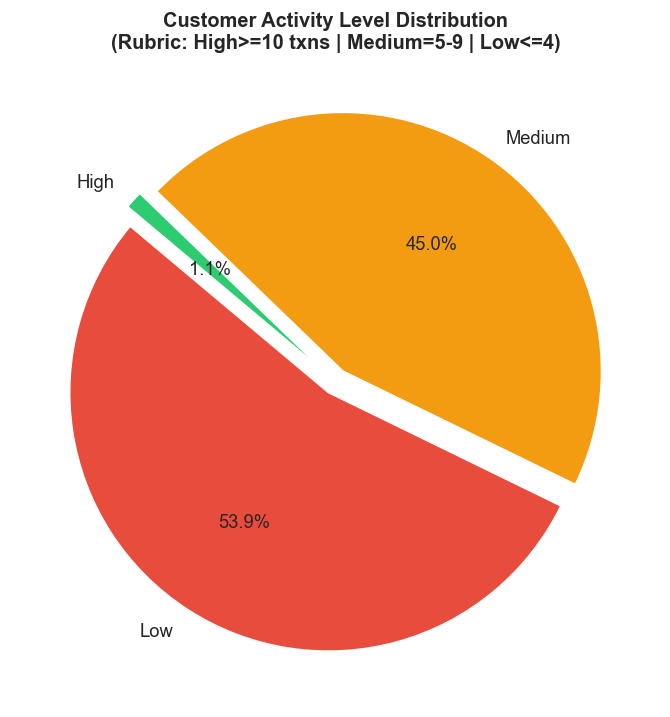

✓ Plot saved: task3_activity_levels.png


In [30]:
# Pie chart for activity levels
fig, ax = plt.subplots(figsize=(7, 7))
colors = {'High': '#2ecc71', 'Medium': '#f39c12', 'Low': '#e74c3c'}
ax.pie(activity_counts.values,
       labels=activity_counts.index,
       autopct='%1.1f%%',
       colors=[colors[l] for l in activity_counts.index],
       startangle=140,
       explode=[0.05]*len(activity_counts))
ax.set_title('Customer Activity Level Distribution\n(Rubric: High>=10 txns | Medium=5-9 | Low<=4)',
             fontsize=12, fontweight='bold')
plt.savefig('task3_activity_levels.png', bbox_inches='tight')
plt.show()
print("✓ Plot saved: task3_activity_levels.png")

In [31]:
# --- Step 3.3: Balance and Volume Segmentation ---
balance_q33 = customer_summary['AvgBalance'].quantile(0.33)
balance_q66 = customer_summary['AvgBalance'].quantile(0.66)
volume_q33  = customer_summary['TotalAmount'].quantile(0.33)
volume_q66  = customer_summary['TotalAmount'].quantile(0.66)
 
def balance_segment(bal):
    if bal >= balance_q66:
        return 'High Balance'
    elif bal >= balance_q33:
        return 'Medium Balance'
    else:
        return 'Low Balance'
 
def volume_segment(vol):
    if vol >= volume_q66:
        return 'High Volume'
    elif vol >= volume_q33:
        return 'Medium Volume'
    else:
        return 'Low Volume'
 
customer_summary['BalanceSegment'] = customer_summary['AvgBalance'].apply(balance_segment)
customer_summary['VolumeSegment']  = customer_summary['TotalAmount'].apply(volume_segment)
 
print("\n--- Balance Segmentation ---")
print(customer_summary['BalanceSegment'].value_counts())
print("\n--- Volume Segmentation ---")
print(customer_summary['VolumeSegment'].value_counts())


--- Balance Segmentation ---
BalanceSegment
High Balance      61
Low Balance       60
Medium Balance    59
Name: count, dtype: int64

--- Volume Segmentation ---
VolumeSegment
High Volume      61
Low Volume       60
Medium Volume    59
Name: count, dtype: int64


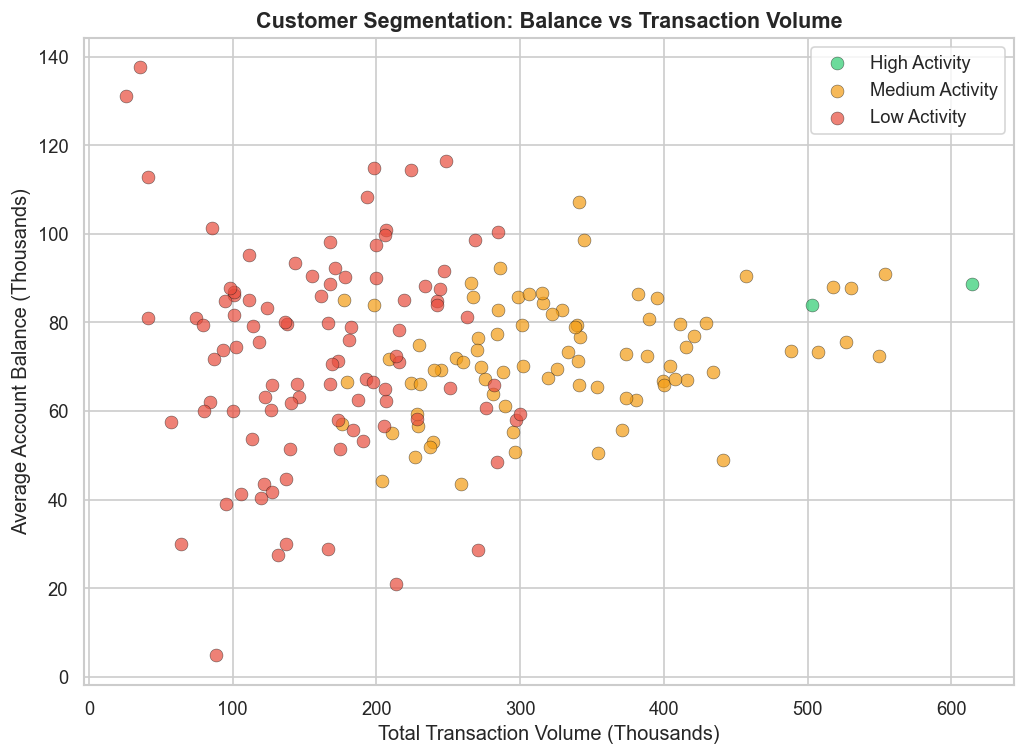

✓ Plot saved: task3_balance_vs_volume.png


In [32]:
# Scatter plot: Balance vs Volume coloured by Activity Level
fig, ax = plt.subplots(figsize=(10, 7))
for level, color in colors.items():
    subset = customer_summary[customer_summary['ActivityLevel'] == level]
    ax.scatter(subset['TotalAmount']/1e3, subset['AvgBalance']/1e3,
               label=f'{level} Activity', alpha=0.7, color=color, s=60, edgecolors='k', linewidths=0.3)
ax.set_xlabel('Total Transaction Volume (Thousands)', fontsize=12)
ax.set_ylabel('Average Account Balance (Thousands)', fontsize=12)
ax.set_title('Customer Segmentation: Balance vs Transaction Volume', fontsize=13, fontweight='bold')
ax.legend()
plt.savefig('task3_balance_vs_volume.png', bbox_inches='tight')
plt.show()
print("✓ Plot saved: task3_balance_vs_volume.png")

In [33]:
# --- Step 3.4: Customer Profiles ---
# Profile 1: High Net Inflow Accounts
high_inflow_threshold = customer_summary['NetInflow'].quantile(0.75)
high_inflow = customer_summary[customer_summary['NetInflow'] >= high_inflow_threshold]
print(f"\n--- Profile 1: High Net Inflow Accounts (NetInflow >= {high_inflow_threshold:,.0f}) ---")
print(f"Count: {len(high_inflow)}")
print(high_inflow[['CustomerID','NetInflow','TxnCount','AvgBalance','ActivityLevel']].head(10).to_string(index=False))


--- Profile 1: High Net Inflow Accounts (NetInflow >= 10,302) ---
Count: 45
CustomerID  NetInflow  TxnCount   AvgBalance ActivityLevel
  CUST1189   80405.33         3 39051.940000           Low
  CUST1644   68894.37         4 65243.095000           Low
  CUST2427   22367.03         4 83209.562500           Low
  CUST2443  300537.89         5 66831.064000        Medium
  CUST2541   76746.33         2 65945.350000           Low
  CUST2612   88078.01         5 76607.100000        Medium
  CUST2694  242421.36         3 84864.646667           Low
  CUST2942  141004.79         5 85163.818000        Medium
  CUST3015   51871.31         2 71682.780000           Low
  CUST3041   31500.66         5 43496.780000        Medium


In [34]:
# Profile 2: High-Frequency Low-Balance Accounts
high_freq_low_bal = customer_summary[
    (customer_summary['ActivityLevel'] == 'High') &
    (customer_summary['BalanceSegment'] == 'Low Balance')
]
print(f"\n--- Profile 2: High-Frequency Low-Balance Accounts ---")
print(f"Count: {len(high_freq_low_bal)}")
print(high_freq_low_bal[['CustomerID','TxnCount','AvgBalance','NetInflow']].head(10).to_string(index=False))


--- Profile 2: High-Frequency Low-Balance Accounts ---
Count: 0
Empty DataFrame
Columns: [CustomerID, TxnCount, AvgBalance, NetInflow]
Index: []


In [35]:
# Profile 3: Negative or Near-Zero Balance Accounts
near_zero_threshold = customer_summary['AvgBalance'].quantile(0.10)
neg_near_zero = customer_summary[customer_summary['AvgBalance'] <= near_zero_threshold]
print(f"\n--- Profile 3: Negative/Near-Zero Balance Accounts (AvgBalance <= {near_zero_threshold:,.0f}) ---")
print(f"Count: {len(neg_near_zero)}")
print(neg_near_zero[['CustomerID','AvgBalance','TxnCount','NetInflow']].head(10).to_string(index=False))


--- Profile 3: Negative/Near-Zero Balance Accounts (AvgBalance <= 50,393) ---
Count: 18
CustomerID   AvgBalance  TxnCount  NetInflow
  CUST1189 39051.940000         3   80405.33
  CUST2067 41295.800000         2  -67483.62
  CUST2109 29965.900000         1  -64067.19
  CUST2464  4873.360000         1  -88577.01
  CUST3041 43496.780000         5   31500.66
  CUST3315 48822.111429         7 -393394.78
  CUST3810 30028.380000         2 -137470.26
  CUST4003 27368.452500         4  116367.56
  CUST5255 28882.865000         2  166349.92
  CUST5894 43470.242500         4  133063.31


In [36]:
print("\n" + "=" * 60)
print("TASK 4: FINANCIAL RISK IDENTIFICATION")
print("=" * 60)


TASK 4: FINANCIAL RISK IDENTIFICATION


In [37]:
# --- Step 4.1: Frequent Large Withdrawals ---
withdrawal_df = df[df['TransactionType'] == 'Withdrawal']
withdrawal_threshold = withdrawal_df['TransactionAmount'].quantile(0.90)
large_withdrawals = withdrawal_df[withdrawal_df['TransactionAmount'] >= withdrawal_threshold]
 
large_wd_by_acc = large_withdrawals.groupby('AccountID').agg(
    LargeWithdrawalCount = ('TransactionID', 'count'),
    TotalWithdrawn       = ('TransactionAmount', 'sum')
).reset_index().sort_values('LargeWithdrawalCount', ascending=False)
 
print(f"\n--- Accounts with Frequent Large Withdrawals (Top 90th percentile >= {withdrawal_threshold:,.2f}) ---")
print(large_wd_by_acc.head(10).to_string(index=False))
 


--- Accounts with Frequent Large Withdrawals (Top 90th percentile >= 89,043.29) ---
AccountID  LargeWithdrawalCount  TotalWithdrawn
 ACC71938                     2       199945.24
 ACC97411                     2       253344.76
 ACC78581                     2       194934.22
 ACC21264                     1       121732.21
 ACC19156                     1        94882.00
 ACC10996                     1       104027.85
 ACC24070                     1        99268.01
 ACC49422                     1        90428.24
 ACC28612                     1       101279.80
 ACC30852                     1        91479.54


In [38]:
# --- Step 4.2: Overdraft Detection ---
overdraft_accounts = df[df['AccountBalance'] < 0]['AccountID'].unique()
print(f"\n--- Overdraft Accounts (AccountBalance < 0) ---")
print(f"Count: {len(overdraft_accounts)}")
overdraft_df = df[df['AccountBalance'] < 0][['AccountID','CustomerID','AccountBalance','TransactionDate']].sort_values('AccountBalance')
print(overdraft_df.head(10).to_string(index=False))


--- Overdraft Accounts (AccountBalance < 0) ---
Count: 17
AccountID CustomerID  AccountBalance TransactionDate
 ACC39529   CUST6565       -35891.00      2023-02-05
 ACC34821   CUST3315       -32532.52      2023-02-04
 ACC46953   CUST9731       -26968.23      2023-10-24
 ACC78589   CUST2578       -25971.51      2023-09-06
 ACC45521   CUST1962       -18963.80      2023-10-22
 ACC64022   CUST3153       -11356.98      2024-01-29
 ACC88516   CUST9843        -9208.20      2023-01-13
 ACC11062   CUST6210        -9084.22      2023-02-14
 ACC74631   CUST6210        -8820.48      2023-01-08
 ACC15671   CUST5610        -8225.60      2024-02-05


In [39]:
# --- Step 4.3: Balance Volatility (Standard Deviation and CV) ---
volatility = df.groupby('AccountID')['AccountBalance'].agg(['mean', 'std']).reset_index()
volatility.columns = ['AccountID', 'MeanBalance', 'StdBalance']
volatility['CV'] = volatility['StdBalance'] / volatility['MeanBalance'].abs()  # Coefficient of Variation
volatility.dropna(inplace=True)
volatility = volatility.sort_values('CV', ascending=False)
 
print(f"\n--- Top 10 High Volatility Accounts (by Coefficient of Variation) ---")
print(volatility.head(10).to_string(index=False))


--- Top 10 High Volatility Accounts (by Coefficient of Variation) ---
AccountID  MeanBalance   StdBalance       CV
 ACC78589 34272.666667 86423.144143 2.521635
 ACC46953 35656.160000 88564.261673 2.483842
 ACC34821 23319.337500 48974.249053 2.100156
 ACC39529 62774.933333 91165.111334 1.452253
 ACC15671 27077.566667 30995.761438 1.144703
 ACC87602 41022.300000 46348.766642 1.129843
 ACC38559 66090.740000 70149.362614 1.061410
 ACC28612 42258.706667 44658.869028 1.056797
 ACC97225 53496.773333 51171.427756 0.956533
 ACC76699 46970.956667 44554.664838 0.948558


In [40]:
# --- Step 4.4: Anomaly Detection using IQR and Z-Score ---
# IQR Method on TransactionAmount
Q1 = df['TransactionAmount'].quantile(0.25)
Q3 = df['TransactionAmount'].quantile(0.75)
IQR = Q3 - Q1
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR
 
iqr_outliers = df[(df['TransactionAmount'] < lower_bound) | (df['TransactionAmount'] > upper_bound)]
print(f"\n--- IQR Anomaly Detection ---")
print(f"IQR Range: [{lower_bound:,.2f}, {upper_bound:,.2f}]")
print(f"Outlier transactions: {len(iqr_outliers)}")


--- IQR Anomaly Detection ---
IQR Range: [-23,726.62, 131,812.85]
Outlier transactions: 7


In [41]:
# Z-Score Method on TransactionAmount
df['ZScore_Amount'] = np.abs(stats.zscore(df['TransactionAmount'].dropna()))
zscore_outliers = df[df['ZScore_Amount'] > 3]
print(f"\n--- Z-Score Anomaly Detection (|Z| > 3) ---")
print(f"Outlier transactions: {len(zscore_outliers)}")
if len(zscore_outliers) > 0:
    print(zscore_outliers[['TransactionID','AccountID','TransactionAmount','ZScore_Amount']].head(10).to_string(index=False))


--- Z-Score Anomaly Detection (|Z| > 3) ---
Outlier transactions: 4
 TransactionID AccountID  TransactionAmount  ZScore_Amount
           141  ACC21719          155241.43       3.396728
           133  ACC18057          144421.84       3.031914
           190  ACC41829          144271.27       3.026837
            30  ACC45101          165004.54       3.725920


In [42]:
# --- Step 4.5: Suspicious/Irregular Behavior Flagging ---
# Flag customers with: high large withdrawal count + overdraft
suspicious_customers = set(large_withdrawals['CustomerID'].unique()) & \
                       set(df[df['AccountBalance'] < 0]['CustomerID'].unique())
print(f"\n--- Suspicious Customers (Large Withdrawals + Overdraft) ---")
print(f"Count: {len(suspicious_customers)}")
print(list(suspicious_customers)[:10])


--- Suspicious Customers (Large Withdrawals + Overdraft) ---
Count: 2
['CUST1962', 'CUST3315']


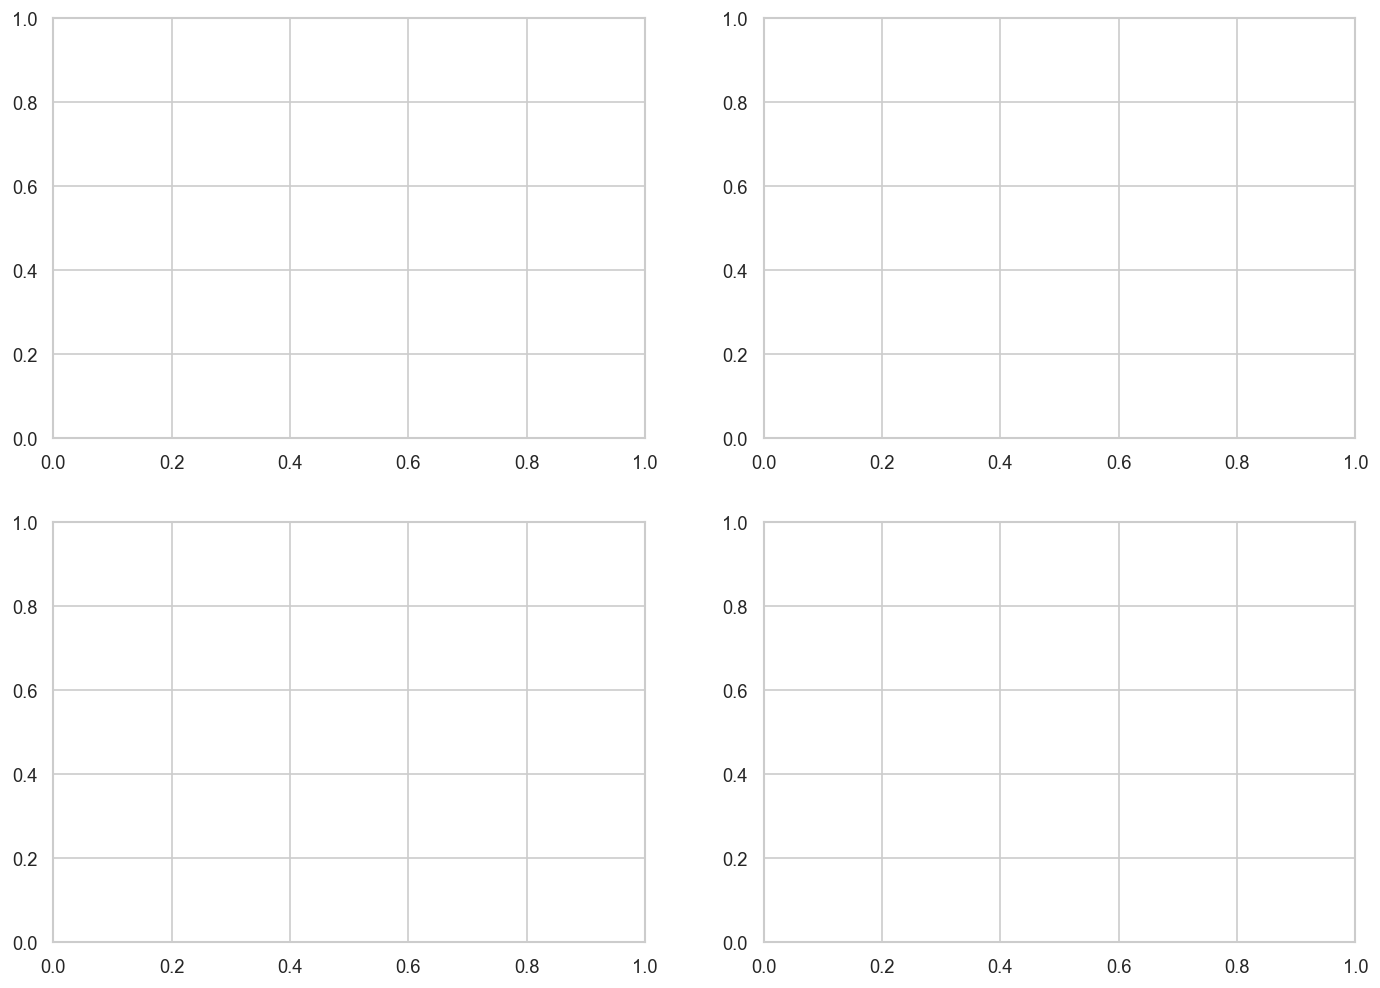

In [43]:
# Risk Dashboard Visualizations
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

In [44]:
# 1. Balance Distribution with overdraft highlighted
axes[0, 0].hist(df['AccountBalance'], bins=40, color='steelblue', alpha=0.7, edgecolor='k')
axes[0, 0].axvline(0, color='red', linestyle='--', linewidth=2, label='Zero Balance')
axes[0, 0].set_title('Account Balance Distribution', fontweight='bold')
axes[0, 0].set_xlabel('Account Balance')
axes[0, 0].set_ylabel('Frequency')
axes[0, 0].legend()

In [45]:
# 2. Large withdrawal accounts
top10_wd = large_wd_by_acc.head(10)
axes[0, 1].barh(top10_wd['AccountID'], top10_wd['LargeWithdrawalCount'], color='salmon', edgecolor='k')
axes[0, 1].set_title('Top 10 Accounts: Frequent Large Withdrawals', fontweight='bold')
axes[0, 1].set_xlabel('Count of Large Withdrawals')

Text(0.5, 509.3333333333333, 'Count of Large Withdrawals')

In [46]:
# 3. Volatility (CV) histogram
axes[1, 0].hist(volatility['CV'].clip(-2, 5), bins=30, color='orange', alpha=0.8, edgecolor='k')
axes[1, 0].set_title('Balance Volatility (Coefficient of Variation)', fontweight='bold')
axes[1, 0].set_xlabel('CV (StdDev / MeanBalance)')
axes[1, 0].set_ylabel('Frequency')

Text(5.333333333333369, 0.5, 'Frequency')

In [47]:
# 4. Z-Score distribution
axes[1, 1].hist(df['ZScore_Amount'].dropna(), bins=40, color='purple', alpha=0.7, edgecolor='k')
axes[1, 1].axvline(3, color='red', linestyle='--', linewidth=2, label='Z=3 (Anomaly Threshold)')
axes[1, 1].set_title('Z-Score Distribution of Transaction Amounts', fontweight='bold')
axes[1, 1].set_xlabel('Z-Score')
axes[1, 1].set_ylabel('Frequency')
axes[1, 1].legend()
 
plt.suptitle('Task 4: Financial Risk Identification', fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('task4_risk_dashboard.png', bbox_inches='tight')
plt.show()
print("✓ Plot saved: task4_risk_dashboard.png")

<Figure size 768x576 with 0 Axes>

✓ Plot saved: task4_risk_dashboard.png


In [48]:
print("\n" + "=" * 60)
print("TASK 5: EXTENSIVE EDA VISUALISATIONS")
print("=" * 60)


TASK 5: EXTENSIVE EDA VISUALISATIONS


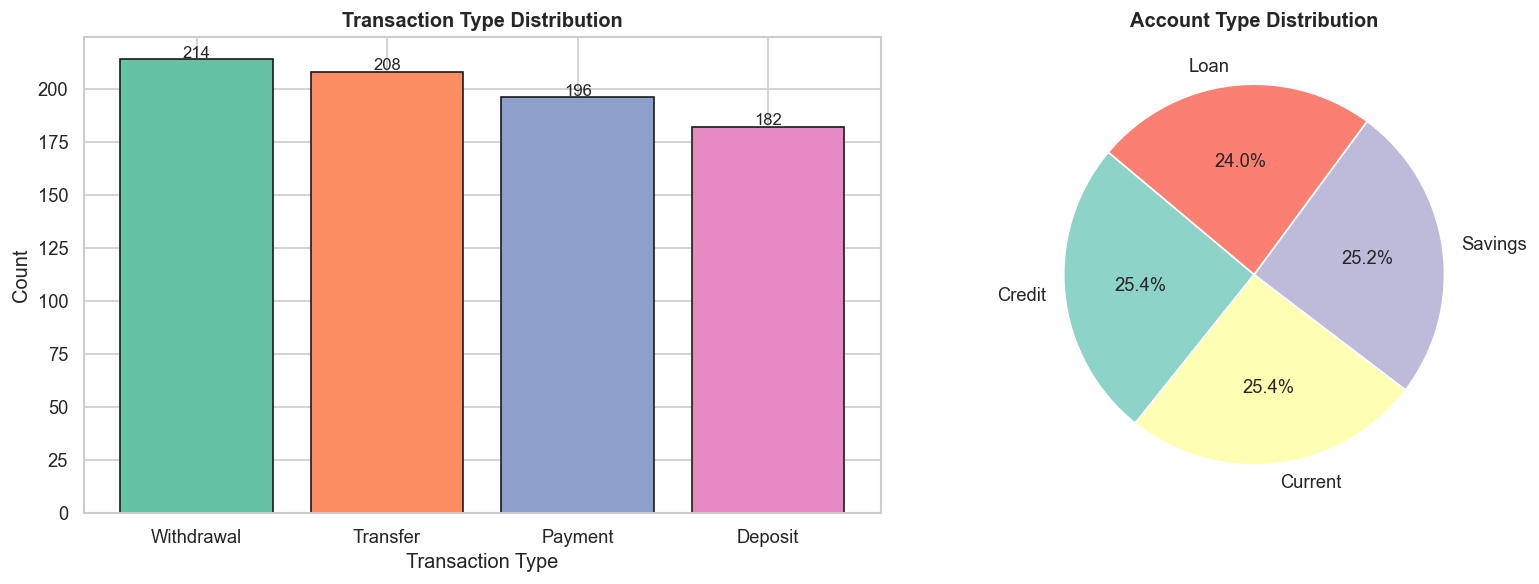

In [49]:
# --- Plot 1: Transaction Type Distribution ---
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
txn_counts = df['TransactionType'].value_counts()
axes[0].bar(txn_counts.index, txn_counts.values,
            color=sns.color_palette("Set2", len(txn_counts)), edgecolor='k')
axes[0].set_title('Transaction Type Distribution', fontweight='bold')
axes[0].set_xlabel('Transaction Type')
axes[0].set_ylabel('Count')
for i, v in enumerate(txn_counts.values):
    axes[0].text(i, v + 1, str(v), ha='center', fontsize=10)
 
acc_counts = df['AccountType'].value_counts()
axes[1].pie(acc_counts.values, labels=acc_counts.index,
            autopct='%1.1f%%', colors=sns.color_palette("Set3", len(acc_counts)),
            startangle=140)
axes[1].set_title('Account Type Distribution', fontweight='bold')
plt.tight_layout()
plt.savefig('task5_txn_type_distribution.png', bbox_inches='tight')
plt.show()

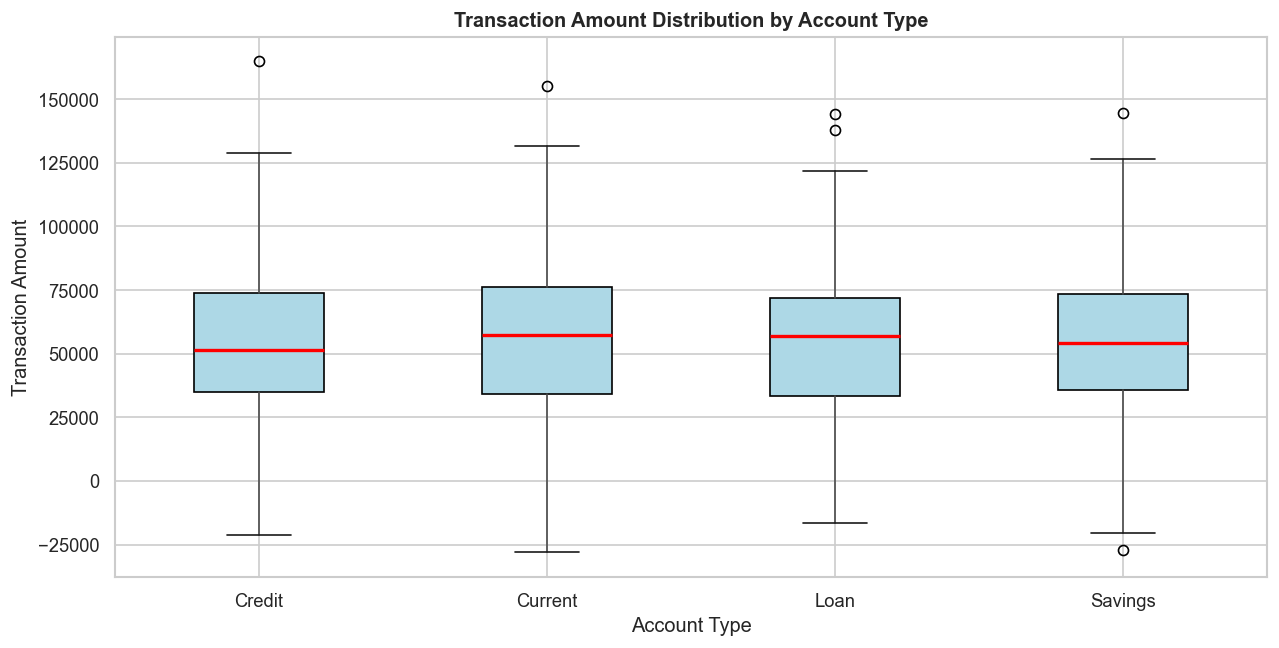

In [50]:
# --- Plot 2: Transaction Amount by Account Type (Boxplot) ---
fig, ax = plt.subplots(figsize=(12, 6))
df.boxplot(column='TransactionAmount', by='AccountType', ax=ax,
           patch_artist=True,
           boxprops=dict(facecolor='lightblue'),
           medianprops=dict(color='red', linewidth=2))
ax.set_title('Transaction Amount Distribution by Account Type', fontweight='bold')
ax.set_xlabel('Account Type')
ax.set_ylabel('Transaction Amount')
plt.suptitle('')
plt.savefig('task5_boxplot_by_accounttype.png', bbox_inches='tight')
plt.show()

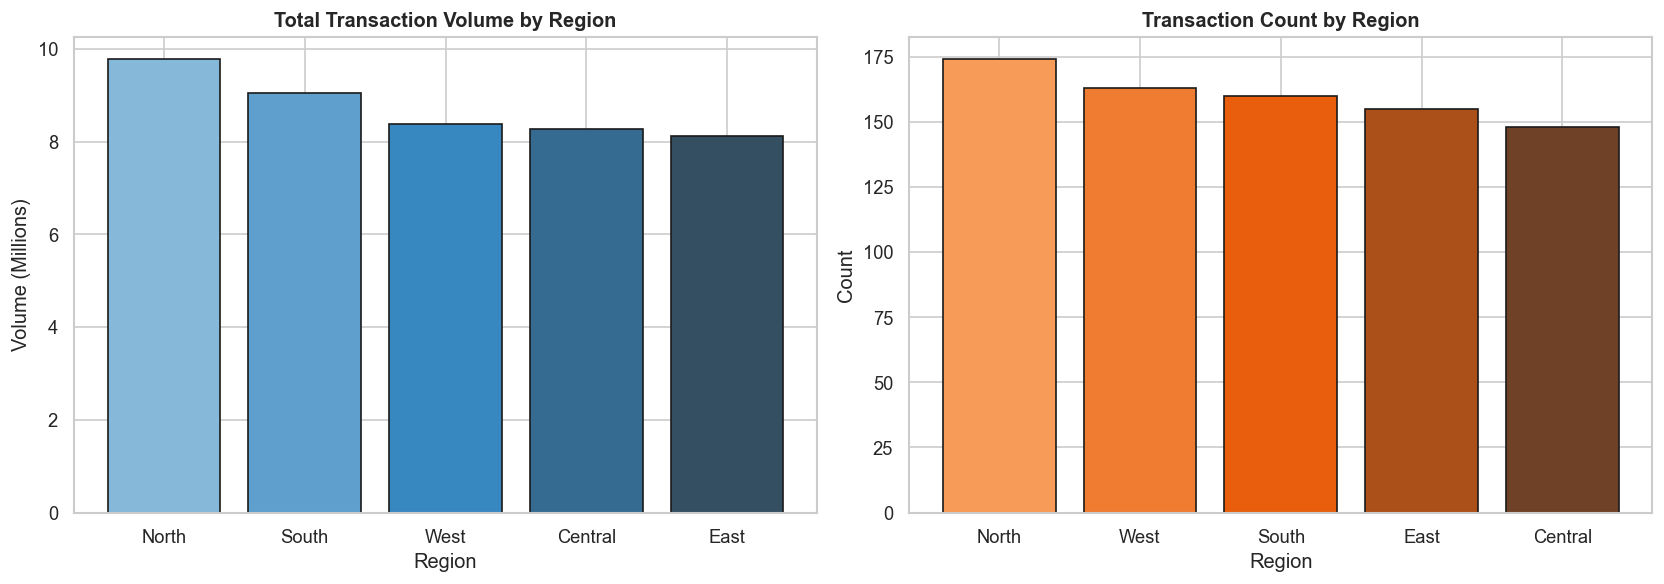

In [51]:
# --- Plot 3: Regional Transaction Analysis ---
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
region_vol = df.groupby('Region')['TransactionAmount'].sum().sort_values(ascending=False)
axes[0].bar(region_vol.index, region_vol.values / 1e6,
            color=sns.color_palette("Blues_d", len(region_vol)), edgecolor='k')
axes[0].set_title('Total Transaction Volume by Region', fontweight='bold')
axes[0].set_xlabel('Region')
axes[0].set_ylabel('Volume (Millions)')
 
region_count = df.groupby('Region')['TransactionID'].count().sort_values(ascending=False)
axes[1].bar(region_count.index, region_count.values,
            color=sns.color_palette("Oranges_d", len(region_count)), edgecolor='k')
axes[1].set_title('Transaction Count by Region', fontweight='bold')
axes[1].set_xlabel('Region')
axes[1].set_ylabel('Count')
plt.tight_layout()
plt.savefig('task5_regional_analysis.png', bbox_inches='tight')
plt.show()

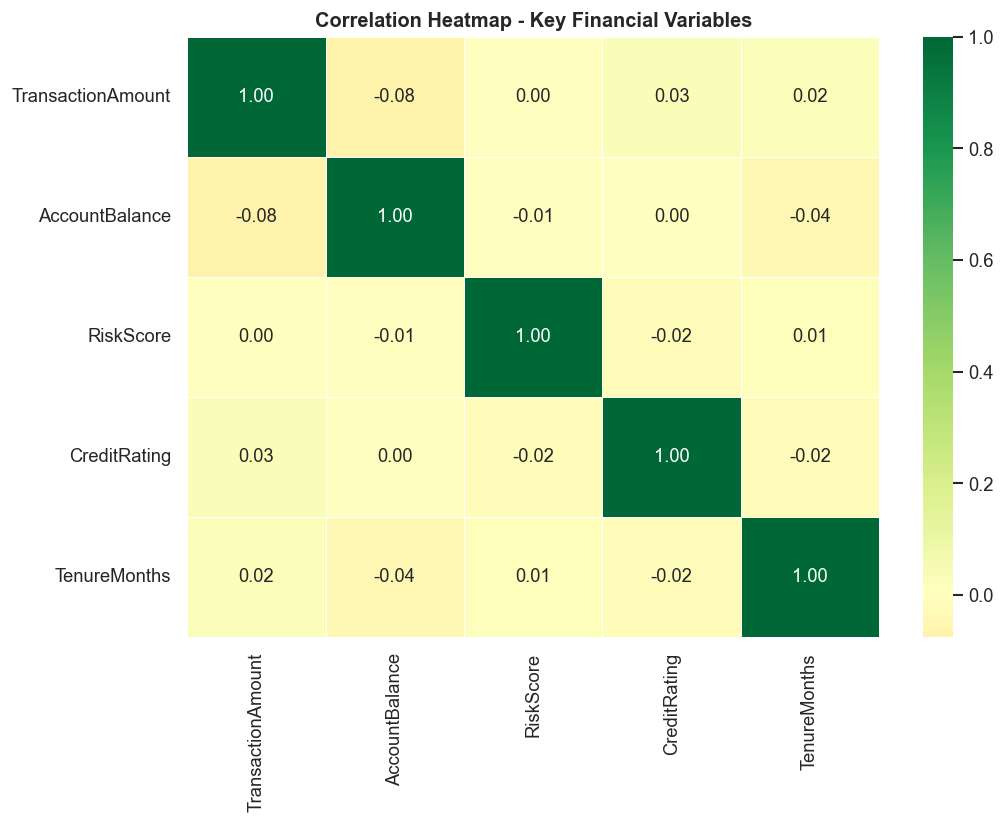

In [52]:
# --- Plot 4: Correlation Heatmap ---
fig, ax = plt.subplots(figsize=(9, 7))
numeric_cols = ['TransactionAmount', 'AccountBalance', 'RiskScore', 'CreditRating', 'TenureMonths']
corr = df[numeric_cols].corr()
sns.heatmap(corr, annot=True, fmt='.2f', cmap='RdYlGn', ax=ax,
            center=0, linewidths=0.5, linecolor='white')
ax.set_title('Correlation Heatmap - Key Financial Variables', fontweight='bold')
plt.tight_layout()
plt.savefig('task5_correlation_heatmap.png', bbox_inches='tight')
plt.show()

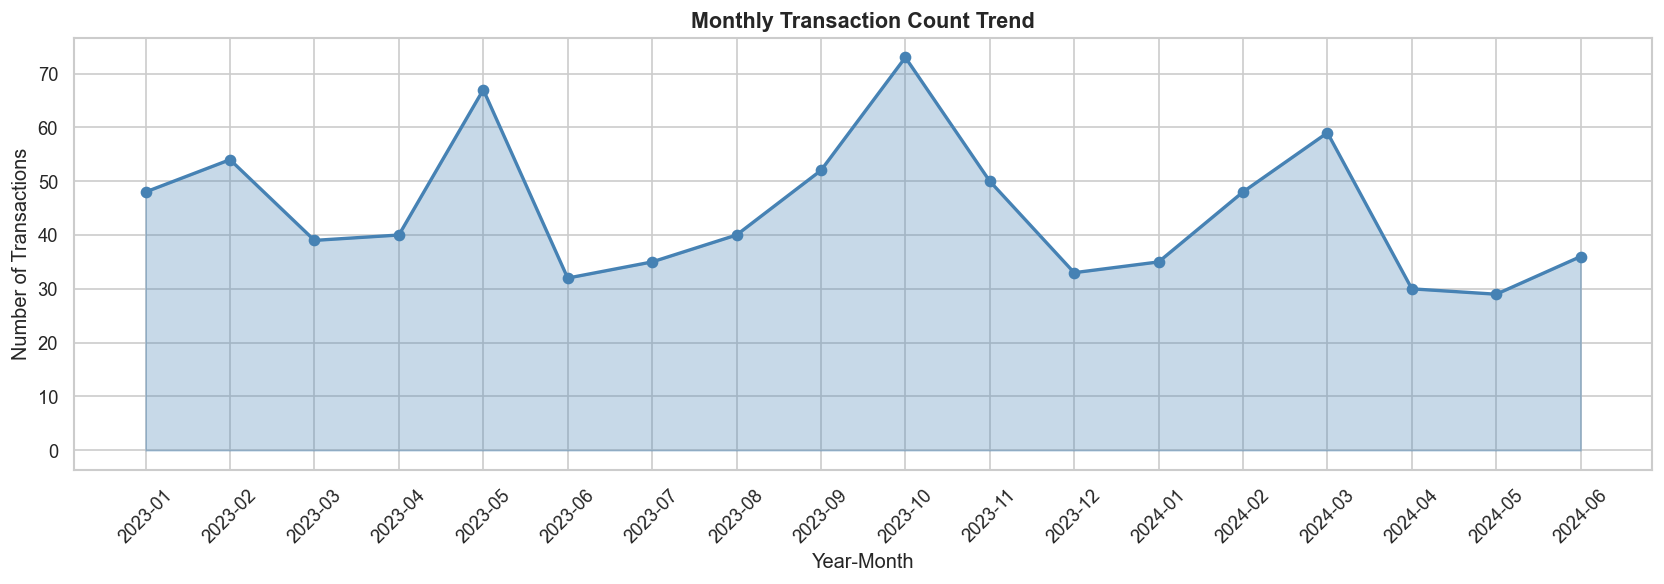

In [53]:
# --- Plot 5: Monthly Transaction Count Trend ---
monthly_count = df.groupby('YearMonth')['TransactionID'].count().reset_index()
monthly_count['YearMonth_str'] = monthly_count['YearMonth'].astype(str)
 
fig, ax = plt.subplots(figsize=(14, 5))
ax.plot(monthly_count['YearMonth_str'], monthly_count['TransactionID'],
        marker='o', color='steelblue', linewidth=2)
ax.fill_between(monthly_count['YearMonth_str'], monthly_count['TransactionID'], alpha=0.3, color='steelblue')
ax.set_title('Monthly Transaction Count Trend', fontweight='bold', fontsize=13)
ax.set_xlabel('Year-Month')
ax.set_ylabel('Number of Transactions')
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig('task5_monthly_txn_count.png', bbox_inches='tight')
plt.show()

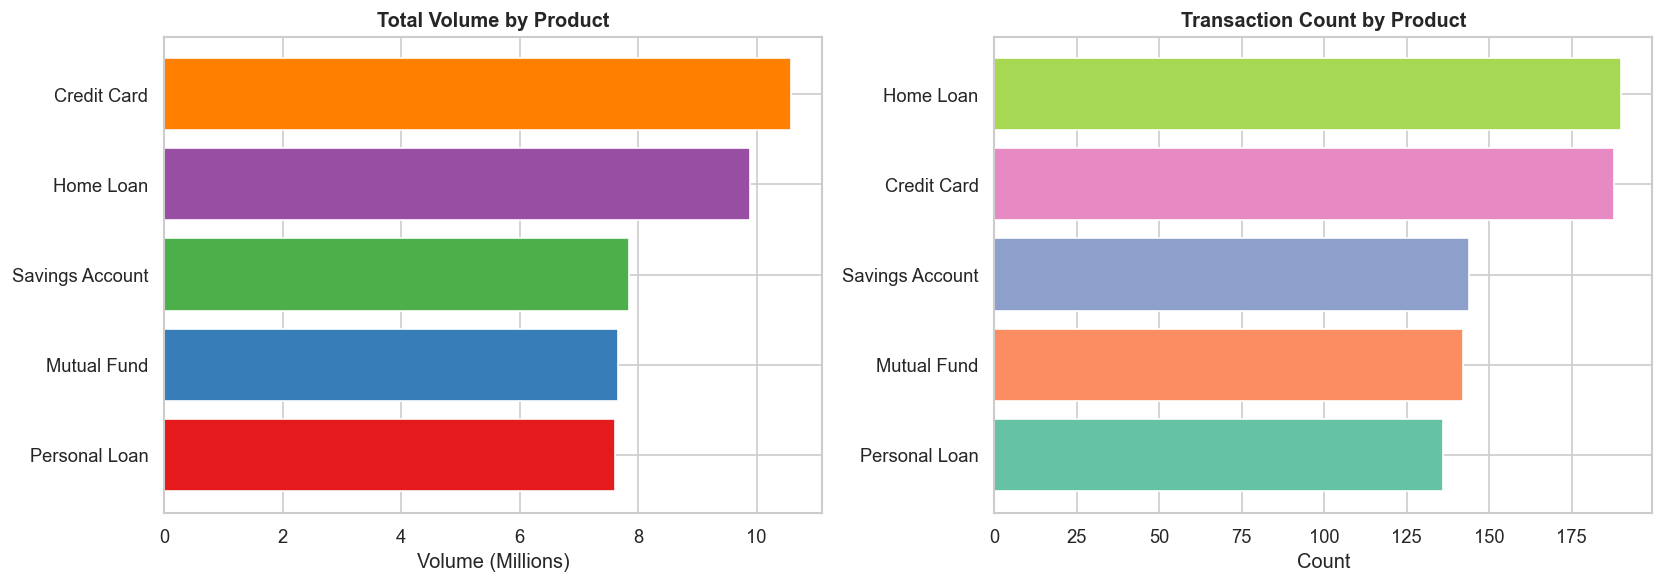

In [54]:
# --- Plot 6: Product-wise Transaction Analysis ---
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
product_vol = df.groupby('Product')['TransactionAmount'].sum().sort_values()
axes[0].barh(product_vol.index, product_vol.values / 1e6,
             color=sns.color_palette("Set1", len(product_vol)))
axes[0].set_title('Total Volume by Product', fontweight='bold')
axes[0].set_xlabel('Volume (Millions)')
 
product_cnt = df.groupby('Product')['TransactionID'].count().sort_values()
axes[1].barh(product_cnt.index, product_cnt.values,
             color=sns.color_palette("Set2", len(product_cnt)))
axes[1].set_title('Transaction Count by Product', fontweight='bold')
axes[1].set_xlabel('Count')
plt.tight_layout()
plt.savefig('task5_product_analysis.png', bbox_inches='tight')
plt.show()

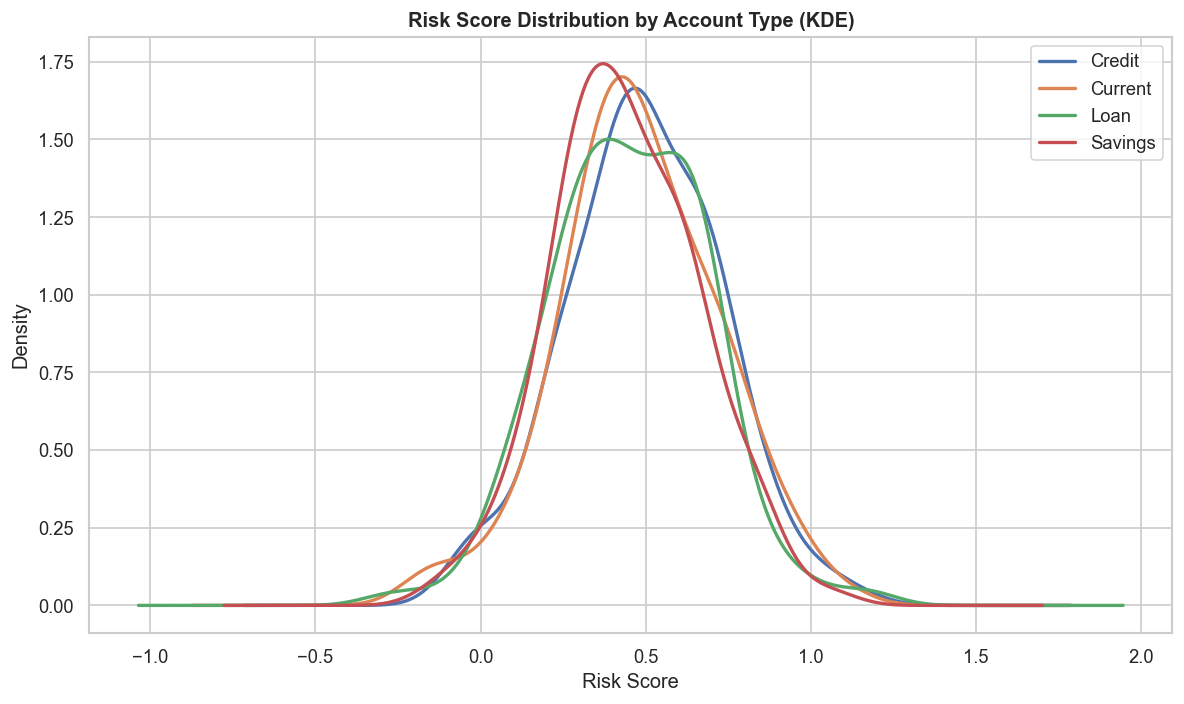

In [55]:
# --- Plot 7: Risk Score Distribution by Account Type ---
fig, ax = plt.subplots(figsize=(10, 6))
for acc_type in df['AccountType'].unique():
    subset = df[df['AccountType'] == acc_type]['RiskScore']
    subset.plot.kde(ax=ax, label=acc_type, linewidth=2)
ax.set_title('Risk Score Distribution by Account Type (KDE)', fontweight='bold')
ax.set_xlabel('Risk Score')
ax.legend()
plt.tight_layout()
plt.savefig('task5_risk_score_kde.png', bbox_inches='tight')
plt.show()

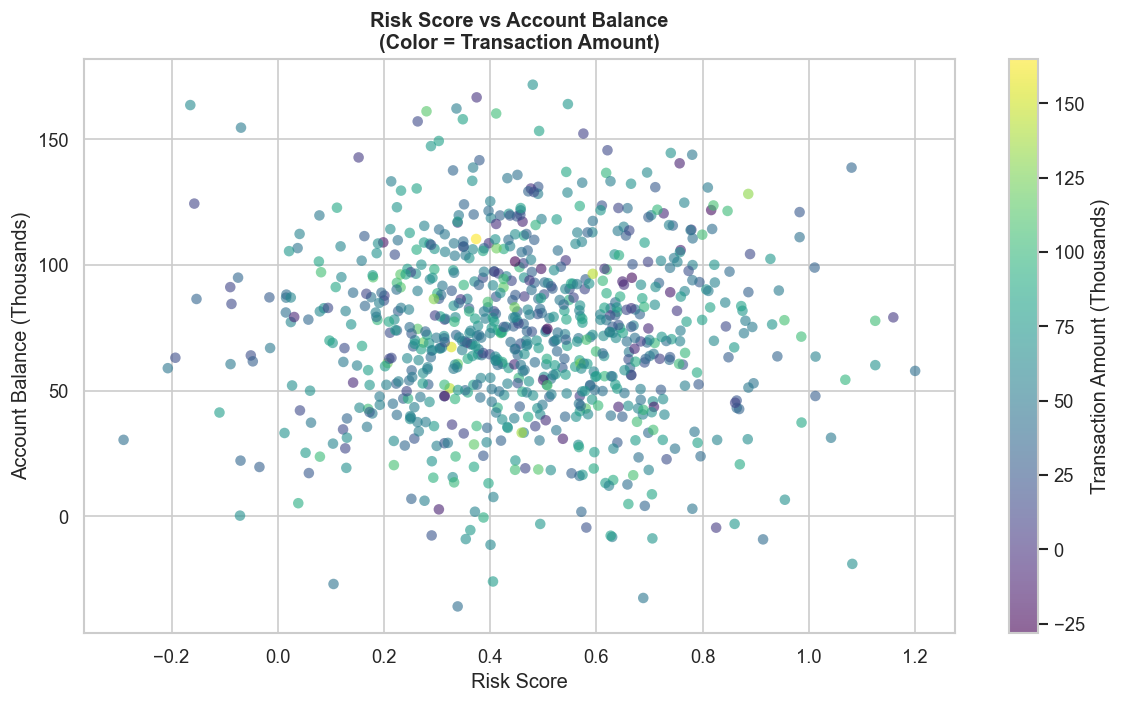

✓ All Task 5 visualizations saved.


In [56]:
# --- Plot 8: RiskScore vs AccountBalance Scatter ---
fig, ax = plt.subplots(figsize=(10, 6))
scatter = ax.scatter(df['RiskScore'], df['AccountBalance']/1e3,
                     c=df['TransactionAmount']/1e3, cmap='viridis',
                     alpha=0.6, s=40, edgecolors='none')
plt.colorbar(scatter, ax=ax, label='Transaction Amount (Thousands)')
ax.set_title('Risk Score vs Account Balance\n(Color = Transaction Amount)', fontweight='bold')
ax.set_xlabel('Risk Score')
ax.set_ylabel('Account Balance (Thousands)')
plt.tight_layout()
plt.savefig('task5_risk_vs_balance_scatter.png', bbox_inches='tight')
plt.show()
 
print("✓ All Task 5 visualizations saved.")

In [57]:
print("\n" + "=" * 60)
print("TASK 6: HYPOTHESIS TESTING")
print("=" * 60)


TASK 6: HYPOTHESIS TESTING


In [58]:
# --- Hypothesis 1: High-volume accounts have higher avg balances than low-volume ---
# Step 6.1: Classify customers into High and Low volume based on TxnCount
median_txn = customer_summary['TxnCount'].median()
high_vol = customer_summary[customer_summary['TxnCount'] >= median_txn]['AvgBalance']
low_vol  = customer_summary[customer_summary['TxnCount'] <  median_txn]['AvgBalance']
 
print(f"\n--- Hypothesis 1 ---")
print("H0: High-volume and Low-volume accounts have SAME average balance")
print("H1: High-volume accounts have STATISTICALLY HIGHER average balance")
print(f"\nMedian TxnCount threshold used: {median_txn}")
print(f"High Volume Group - N={len(high_vol)}, Mean Balance={high_vol.mean():,.2f}, Std={high_vol.std():,.2f}")
print(f"Low Volume Group  - N={len(low_vol)}, Mean Balance={low_vol.mean():,.2f}, Std={low_vol.std():,.2f}")
 
# Levene's test for equal variance
lev_stat, lev_p = stats.levene(high_vol, low_vol)
print(f"\nLevene's Test for Equal Variance: stat={lev_stat:.4f}, p={lev_p:.4f}")
equal_var = lev_p > 0.05


--- Hypothesis 1 ---
H0: High-volume and Low-volume accounts have SAME average balance
H1: High-volume accounts have STATISTICALLY HIGHER average balance

Median TxnCount threshold used: 4.0
High Volume Group - N=116, Mean Balance=72,226.87, Std=15,834.25
Low Volume Group  - N=64, Mean Balance=73,282.34, Std=24,884.71

Levene's Test for Equal Variance: stat=12.3658, p=0.0006


In [59]:
# Independent samples t-test
t_stat, p_val = stats.ttest_ind(high_vol, low_vol, equal_var=equal_var, alternative='greater')
print(f"\nIndependent Samples t-test (one-tailed):")
print(f"  t-statistic = {t_stat:.4f}")
print(f"  p-value     = {p_val:.4f}")
print(f"  Significance level (alpha) = 0.05")
 
if p_val < 0.05:
    print("\n✅ RESULT: REJECT H0 — High-volume accounts DO have statistically higher average balances (p < 0.05)")
else:
    print("\n❌ RESULT: FAIL TO REJECT H0 — No significant difference found (p >= 0.05)")


Independent Samples t-test (one-tailed):
  t-statistic = -0.3068
  p-value     = 0.6201
  Significance level (alpha) = 0.05

❌ RESULT: FAIL TO REJECT H0 — No significant difference found (p >= 0.05)


In [60]:
# --- Hypothesis 2: Activity Level affects Average Balance ---
high_act  = customer_summary[customer_summary['ActivityLevel'] == 'High']['AvgBalance']
medium_act = customer_summary[customer_summary['ActivityLevel'] == 'Medium']['AvgBalance']
low_act   = customer_summary[customer_summary['ActivityLevel'] == 'Low']['AvgBalance']
 
print(f"\n--- Hypothesis 2: One-Way ANOVA ---")
print("H0: Average balance is the same across all activity levels (High, Medium, Low)")
print("H1: At least one activity level group has a different average balance")
print(f"\nHigh Activity   - N={len(high_act)}, Mean={high_act.mean():,.2f}")
print(f"Medium Activity - N={len(medium_act)}, Mean={medium_act.mean():,.2f}")
print(f"Low Activity    - N={len(low_act)}, Mean={low_act.mean():,.2f}")
 
f_stat, anova_p = stats.f_oneway(high_act, medium_act, low_act)
print(f"\nOne-Way ANOVA: F-statistic={f_stat:.4f}, p-value={anova_p:.4f}")
if anova_p < 0.05:
    print("✅ RESULT: REJECT H0 — Significant difference in average balance across activity levels (p < 0.05)")
else:
    print("❌ RESULT: FAIL TO REJECT H0 — No significant difference across activity levels (p >= 0.05)")


--- Hypothesis 2: One-Way ANOVA ---
H0: Average balance is the same across all activity levels (High, Medium, Low)
H1: At least one activity level group has a different average balance

High Activity   - N=2, Mean=86,207.55
Medium Activity - N=81, Mean=72,085.18
Low Activity    - N=97, Mean=72,753.31

One-Way ANOVA: F-statistic=0.5167, p-value=0.5974
❌ RESULT: FAIL TO REJECT H0 — No significant difference across activity levels (p >= 0.05)


Text(0, 0.5, 'Average Balance')

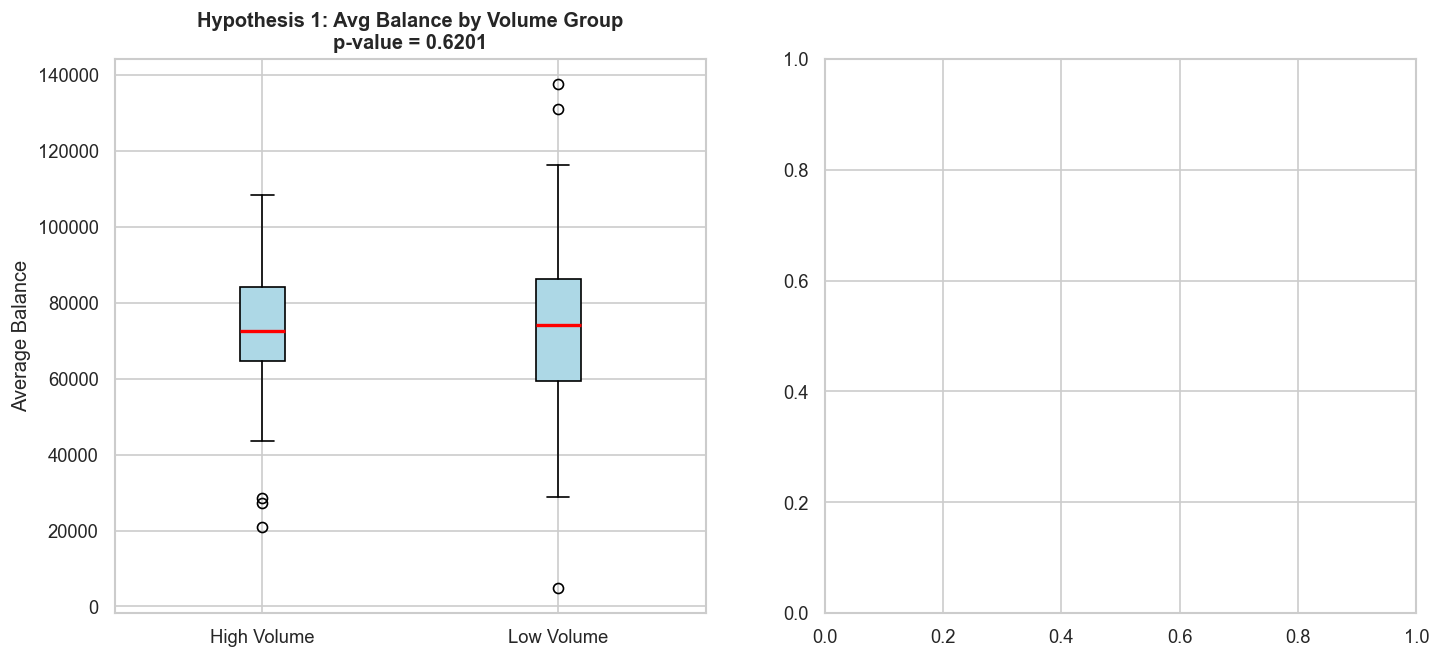

In [61]:
# Visualization: Hypothesis Testing
fig, axes = plt.subplots(1, 2, figsize=(14, 6))
 
# Box plot: High vs Low volume balance
axes[0].boxplot([high_vol.dropna(), low_vol.dropna()],
                labels=['High Volume', 'Low Volume'],
                patch_artist=True,
                boxprops=dict(facecolor='lightblue'),
                medianprops=dict(color='red', linewidth=2))
axes[0].set_title(f'Hypothesis 1: Avg Balance by Volume Group\np-value = {p_val:.4f}', fontweight='bold')
axes[0].set_ylabel('Average Balance')

In [62]:
# Box plot: Activity Level vs Balance
data_for_box = [high_act.dropna(), medium_act.dropna(), low_act.dropna()]
colors_box = ['#2ecc71', '#f39c12', '#e74c3c']
bp = axes[1].boxplot(data_for_box, labels=['High', 'Medium', 'Low'],
                     patch_artist=True, medianprops=dict(color='black', linewidth=2))
for patch, color in zip(bp['boxes'], colors_box):
    patch.set_facecolor(color)
    patch.set_alpha(0.7)
axes[1].set_title(f'Hypothesis 2: Avg Balance by Activity Level\nANOVA p-value = {anova_p:.4f}', fontweight='bold')
axes[1].set_xlabel('Activity Level')
axes[1].set_ylabel('Average Balance')
 
plt.tight_layout()
plt.savefig('task6_hypothesis_testing.png', bbox_inches='tight')
plt.show()
print("✓ Plot saved: task6_hypothesis_testing.png")

<Figure size 768x576 with 0 Axes>

✓ Plot saved: task6_hypothesis_testing.png


In [63]:
print("\n" + "=" * 60)
print("FINAL SUMMARY OF FINDINGS")
print("=" * 60)
print(f"""
Dataset Overview:
  - Total Transactions (cleaned): {len(df)}
  - Unique Customers:             {df['CustomerID'].nunique()}
  - Unique Accounts:              {df['AccountID'].nunique()}
  - Date Range: {df['TransactionDate'].min().date()} to {df['TransactionDate'].max().date()}
 
Key Findings:
  Task 2 - Transactions:
    - Dormant accounts (2+ month gap): {account_summary['DormantFlag'].sum()}
    - Top Net Inflow Account: {account_summary.nlargest(1,'NetInflow')['AccountID'].values[0]}
 
  Task 3 - Customer Profiles:
    - High Activity Customers:  {(customer_summary['ActivityLevel']=='High').sum()}
    - Medium Activity Customers: {(customer_summary['ActivityLevel']=='Medium').sum()}
    - Low Activity Customers:   {(customer_summary['ActivityLevel']=='Low').sum()}
 
  Task 4 - Risk:
    - Overdraft Accounts: {len(overdraft_accounts)}
    - IQR Anomalies: {len(iqr_outliers)}
    - Z-Score Anomalies (|Z|>3): {len(zscore_outliers)}
    - Suspicious Customers: {len(suspicious_customers)}
 
  Task 6 - Hypothesis:
    - H1 (High vol = higher balance): p={p_val:.4f} -> {'REJECTED H0' if p_val<0.05 else 'FAILED TO REJECT'}
    - H2 (Activity affects balance):  p={anova_p:.4f} -> {'REJECTED H0' if anova_p<0.05 else 'FAILED TO REJECT'}
""")
 
print("=" * 60)
print("ALL TASKS COMPLETE. Check saved .png files for plots.")
print("=" * 60)


FINAL SUMMARY OF FINDINGS

Dataset Overview:
  - Total Transactions (cleaned): 800
  - Unique Customers:             180
  - Unique Accounts:              192
  - Date Range: 2023-01-06 to 2024-06-22

Key Findings:
  Task 2 - Transactions:
    - Dormant accounts (2+ month gap): 172
    - Top Net Inflow Account: ACC88286

  Task 3 - Customer Profiles:
    - High Activity Customers:  2
    - Medium Activity Customers: 81
    - Low Activity Customers:   97

  Task 4 - Risk:
    - Overdraft Accounts: 17
    - IQR Anomalies: 7
    - Z-Score Anomalies (|Z|>3): 4
    - Suspicious Customers: 2

  Task 6 - Hypothesis:
    - H1 (High vol = higher balance): p=0.6201 -> FAILED TO REJECT
    - H2 (Activity affects balance):  p=0.5974 -> FAILED TO REJECT

ALL TASKS COMPLETE. Check saved .png files for plots.
